# Week 11 · Day 1 — Detection Fundamentals
### Object Detection with Deep Learning | June 15, 2026 | Campus

**Week 11 Theme:** Object Detection with Deep Learning  
**Daily Deliverable:** NMS from scratch implementation  
**Repository:** `03_June/Week_03/`

---

> *"Object detection = **Where** (bounding box regression) + **What** (classification) — solved simultaneously at every candidate location."*

---

## The Object Detection Pipeline

```
Input Image
     │
     ▼
Backbone CNN ──► Feature Maps  (H × W × C)
     │
     ▼
Anchor Generation ──► K pre-defined boxes per grid cell
     │
     ▼
Detection Head ┌── Classification Head → class scores  (N×K×num_classes)
               └── Regression Head    → box offsets   (N×K×4)  [Δx,Δy,Δw,Δh]
     │
     ▼
Decode Boxes ──► absolute xyxy coordinates + confidence
     │
     ▼
Non-Maximum Suppression ──► Final clean detections
```

Today we implement **every block** of this pipeline from scratch.

## Learning Objectives

| # | Concept | What We Build |
|---|---------|---------------|
| 1 | Bounding box formats | `xyxy ↔ cxcywh` conversion functions |
| 2 | IoU — Intersection over Union | scalar + vectorised (N×M) batched |
| 3 | Anchor boxes | multi-scale · multi-ratio generation |
| 4 | Hard NMS | greedy suppression algorithm from scratch |
| 5 | Soft-NMS | Gaussian score-decay variant |
| 6 | Detection head | dual regression + classification branch |
| 7 | mAP metric | per-class AP · mean average precision |

---

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from itertools import product
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print(f'PyTorch {torch.__version__} | NumPy {np.__version__}')

PyTorch 2.12.0+cpu | NumPy 2.4.0


---
## 1. Bounding Box Representations

Object detectors use two bounding box formats interchangeably:

| Format | Fields | Used in |
|--------|--------|---------|
| **xyxy** | `[x1, y1, x2, y2]` — top-left + bottom-right corners | Loss computation, IoU, NMS |
| **cxcywh** | `[cx, cy, w, h]` — centre + dimensions | Anchor parameterisation, YOLO outputs |

**Why two formats?**
- `xyxy` makes intersection arithmetic trivial: `max(x1_a, x1_b)` is the intersection left edge.
- `cxcywh` makes regression natural: the network predicts *offsets* from anchor centre — `Δcx, Δcy, log(w/w_a), log(h/h_a)`.

The `log` on width/height is crucial — it maps the positive-only ratio to all reals, making gradient updates symmetric.

Original  xyxy   : [ 80  60 280 240]
Converted cxcywh : [180. 150. 200. 180.]  →  centre=(180.0,150.0)  size=(200.0×180.0)
Roundtrip xyxy   : [ 80.  60. 280. 240.]  (matches original: True)


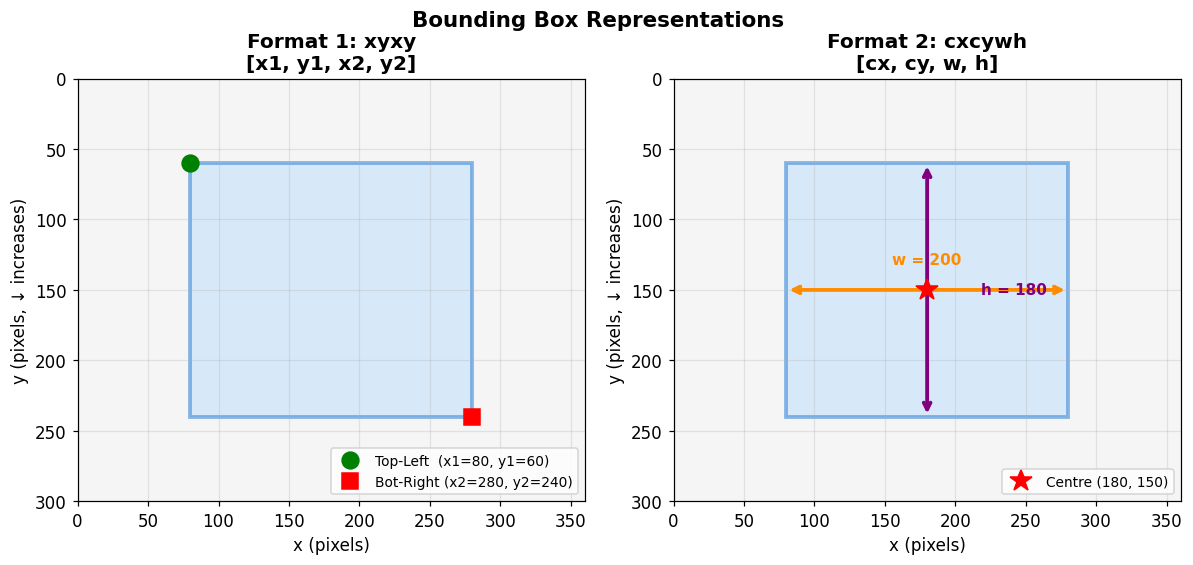

Saved: bbox_formats.png


In [2]:
# ─── Format conversion functions ────────────────────────────────────────────

def xyxy_to_cxcywh(box):
    """[x1, y1, x2, y2]  →  [cx, cy, w, h]"""
    x1, y1, x2, y2 = box
    return np.array([(x1+x2)/2, (y1+y2)/2, x2-x1, y2-y1], dtype=float)

def cxcywh_to_xyxy(box):
    """[cx, cy, w, h]  →  [x1, y1, x2, y2]"""
    cx, cy, w, h = box
    return np.array([cx-w/2, cy-h/2, cx+w/2, cy+h/2], dtype=float)

# Verification
box_xyxy   = np.array([80, 60, 280, 240])
box_cxcywh = xyxy_to_cxcywh(box_xyxy)
roundtrip  = cxcywh_to_xyxy(box_cxcywh)

print(f'Original  xyxy   : {box_xyxy}')
print(f'Converted cxcywh : {box_cxcywh}  →  centre=({box_cxcywh[0]},{box_cxcywh[1]})  size=({box_cxcywh[2]}×{box_cxcywh[3]})')
print(f'Roundtrip xyxy   : {roundtrip}  (matches original: {np.allclose(box_xyxy, roundtrip)})')

# ─── Visualise both formats ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax in axes:
    ax.set_xlim(0, 360); ax.set_ylim(300, 0)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_facecolor('#F5F5F5')
    ax.set_xlabel('x (pixels)'); ax.set_ylabel('y (pixels, ↓ increases)')
    x1, y1, x2, y2 = box_xyxy
    r = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                           linewidth=2.5, edgecolor='#1976D2',
                           facecolor='#BBDEFB', alpha=0.5)
    ax.add_patch(r)

ax = axes[0]
ax.set_title('Format 1: xyxy\n[x1, y1, x2, y2]', fontweight='bold')
x1, y1, x2, y2 = box_xyxy
ax.plot(x1, y1, 'go', ms=11, zorder=5, label=f'Top-Left  (x1={x1}, y1={y1})')
ax.plot(x2, y2, 'rs', ms=11, zorder=5, label=f'Bot-Right (x2={x2}, y2={y2})')
ax.legend(fontsize=9, loc='lower right')

ax = axes[1]
ax.set_title('Format 2: cxcywh\n[cx, cy, w, h]', fontweight='bold')
cx, cy, w, h = box_cxcywh
ax.plot(cx, cy, 'r*', ms=15, zorder=5, label=f'Centre ({cx:.0f}, {cy:.0f})')
ax.annotate('', (cx+w/2, cy), (cx-w/2, cy),
            arrowprops=dict(arrowstyle='<->', color='darkorange', lw=2.5))
ax.text(cx, cy-18, f'w = {w:.0f}', ha='center', color='darkorange',
        fontsize=10, fontweight='bold')
ax.annotate('', (cx, cy+h/2), (cx, cy-h/2),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=2.5))
ax.text(cx+38, cy, f'h = {h:.0f}', va='center', color='purple',
        fontsize=10, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')

plt.suptitle('Bounding Box Representations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bbox_formats.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: bbox_formats.png')

---
## 2. Intersection over Union (IoU)

IoU is the single most important metric in object detection — used in:
- **Training:** matching predictions to ground-truth anchors (IoU ≥ 0.5 → positive)
- **Evaluation:** deciding if a prediction is a True Positive (TP) for mAP
- **NMS:** deciding which overlapping predictions to suppress

$$\text{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{\text{Intersection Area}}{\text{Area}_A + \text{Area}_B - \text{Intersection Area}}$$

**Range:** 0 (no overlap) → 1 (perfect match)

**Computing the intersection rectangle:**
```
inter_x1 = max(box_A.x1, box_B.x1)   # rightmost left edge
inter_y1 = max(box_A.y1, box_B.y1)   # bottommost top edge
inter_x2 = min(box_A.x2, box_B.x2)   # leftmost right edge
inter_y2 = min(box_A.y2, box_B.y2)   # topmost bottom edge

inter_w = max(0, inter_x2 - inter_x1)   ← clamp prevents negative width
inter_h = max(0, inter_y2 - inter_y1)
```

In [3]:
# ─── Scalar IoU ─────────────────────────────────────────────────────────────

def compute_iou(box1, box2):
    """
    Compute IoU between two boxes in xyxy format.
    Handles the no-overlap case via clamp to 0.
    """
    ix1 = max(box1[0], box2[0])
    iy1 = max(box1[1], box2[1])
    ix2 = min(box1[2], box2[2])
    iy2 = min(box1[3], box2[3])

    inter_w = max(0, ix2 - ix1)
    inter_h = max(0, iy2 - iy1)
    intersection = inter_w * inter_h

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - intersection

    return intersection / (union + 1e-6)   # 1e-6 guards against zero-size boxes

# Three test cases
box_a = [50,  50, 250, 250]
box_b = [150, 150, 350, 350]  # partial overlap
box_c = [300, 300, 400, 400]  # no overlap

print(f'IoU(A, B) = {compute_iou(box_a, box_b):.4f}   partial overlap')
print(f'IoU(A, C) = {compute_iou(box_a, box_c):.4f}   no overlap')
print(f'IoU(A, A) = {compute_iou(box_a, box_a):.4f}   perfect match')

IoU(A, B) = 0.1429   partial overlap
IoU(A, C) = 0.0000   no overlap
IoU(A, A) = 1.0000   perfect match


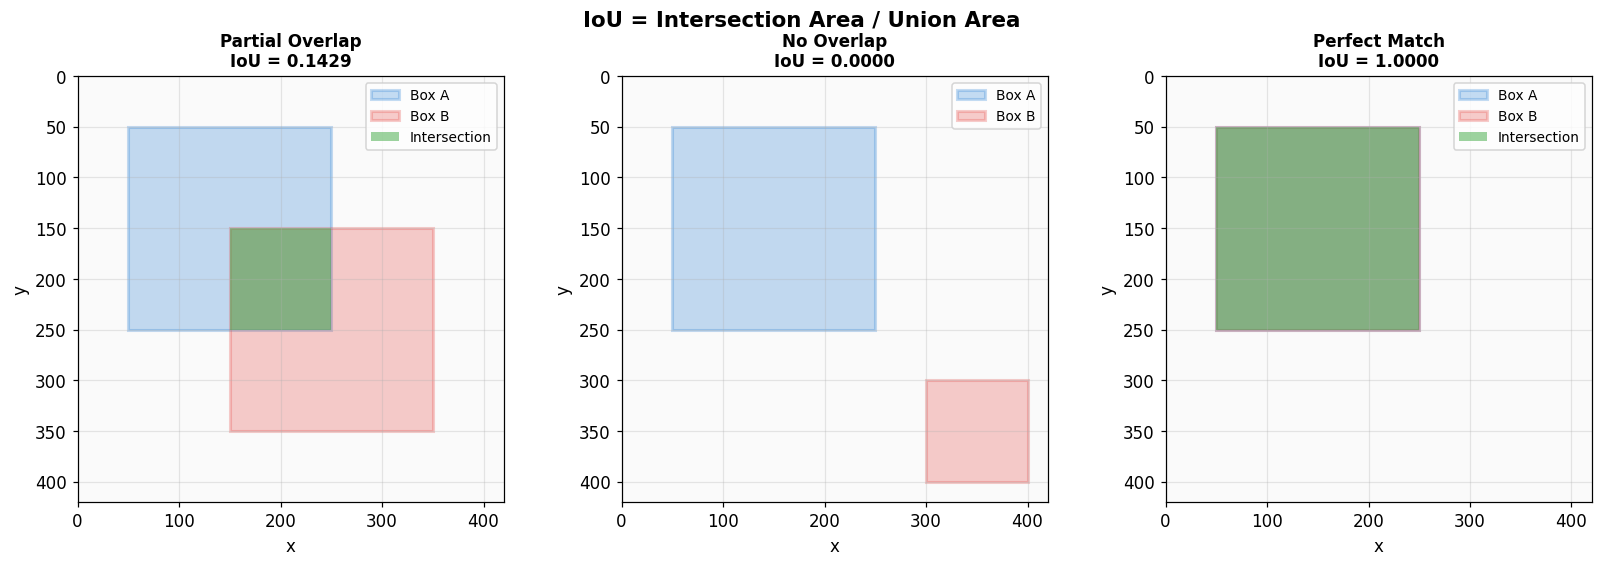

Saved: iou_visualization.png


In [4]:
# ─── IoU Visualisation ──────────────────────────────────────────────────────

cases = [
    ('Partial Overlap', box_a, box_b),
    ('No Overlap',      box_a, box_c),
    ('Perfect Match',   box_a, box_a),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, b1, b2) in zip(axes, cases):
    ax.set_xlim(0, 420); ax.set_ylim(420, 0)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_facecolor('#FAFAFA')
    iou_val = compute_iou(b1, b2)
    ax.set_title(f'{title}\nIoU = {iou_val:.4f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y')

    r1 = patches.Rectangle((b1[0],b1[1]), b1[2]-b1[0], b1[3]-b1[1],
                            linewidth=2, edgecolor='#1976D2', facecolor='#1976D2',
                            alpha=0.25, label='Box A')
    r2 = patches.Rectangle((b2[0],b2[1]), b2[2]-b2[0], b2[3]-b2[1],
                            linewidth=2, edgecolor='#E53935', facecolor='#E53935',
                            alpha=0.25, label='Box B')
    ax.add_patch(r1); ax.add_patch(r2)

    # Draw intersection region in green
    ix1 = max(b1[0], b2[0]); iy1 = max(b1[1], b2[1])
    ix2 = min(b1[2], b2[2]); iy2 = min(b1[3], b2[3])
    if ix2 > ix1 and iy2 > iy1:
        ri = patches.Rectangle((ix1,iy1), ix2-ix1, iy2-iy1,
                               linewidth=0, facecolor='#4CAF50', alpha=0.55,
                               label='Intersection')
        ax.add_patch(ri)
    ax.legend(fontsize=9, loc='upper right')

plt.suptitle('IoU = Intersection Area / Union Area', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('iou_visualization.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: iou_visualization.png')

In [5]:
# ─── Batched (Vectorised) IoU with PyTorch ──────────────────────────────────
#
# During training we need IoU between ALL N predictions and ALL M ground-truth
# boxes simultaneously. Looping is too slow — use broadcasting instead.

def compute_iou_matrix(boxes1, boxes2):
    """
    Vectorised IoU between two sets of boxes.
    boxes1 : (N, 4)  xyxy
    boxes2 : (M, 4)  xyxy
    Returns: (N, M) matrix — iou_matrix[i, j] = IoU(boxes1[i], boxes2[j])
    """
    b1 = torch.tensor(boxes1, dtype=torch.float32).unsqueeze(1)  # (N, 1, 4)
    b2 = torch.tensor(boxes2, dtype=torch.float32).unsqueeze(0)  # (1, M, 4)

    # Intersection corners via broadcasting  → (N, M)
    ix1 = torch.max(b1[...,0], b2[...,0])
    iy1 = torch.max(b1[...,1], b2[...,1])
    ix2 = torch.min(b1[...,2], b2[...,2])
    iy2 = torch.min(b1[...,3], b2[...,3])

    inter = torch.clamp(ix2-ix1, 0) * torch.clamp(iy2-iy1, 0)
    area1 = (b1[...,2]-b1[...,0]) * (b1[...,3]-b1[...,1])
    area2 = (b2[...,2]-b2[...,0]) * (b2[...,3]-b2[...,1])
    union = area1 + area2 - inter

    return (inter / (union + 1e-6)).numpy()

# Demo: 3 predictions vs 2 ground-truth boxes
pred_boxes = [[50,50,200,200], [100,100,300,300], [250,50,400,250]]
gt_boxes   = [[60,60,210,210], [200,150,380,350]]

iou_mat = compute_iou_matrix(pred_boxes, gt_boxes)
print('IoU matrix  (rows=predictions, cols=ground-truth):')
print(f'              GT-0     GT-1')
for i, row in enumerate(iou_mat):
    print(f'  Pred-{i}:    {row[0]:.4f}   {row[1]:.4f}')

print(f'\nShapes: boxes1={np.array(pred_boxes).shape}  boxes2={np.array(gt_boxes).shape}  iou_matrix={iou_mat.shape}')
print('Each prediction can now be matched to its best GT box in O(1) with argmax.')

IoU matrix  (rows=predictions, cols=ground-truth):
              GT-0     GT-1
  Pred-0:    0.7717   0.0000
  Pred-1:    0.2401   0.2459
  Pred-2:    0.0000   0.2453

Shapes: boxes1=(3, 4)  boxes2=(2, 4)  iou_matrix=(3, 2)
Each prediction can now be matched to its best GT box in O(1) with argmax.


---
## 3. Anchor Boxes

**Problem:** A network cannot simultaneously output variable-length lists of boxes. We need a fixed-size output.

**Solution — Anchor boxes:** place a grid of pre-defined boxes (anchors) over the feature map. The network predicts small *offsets* from each anchor, not absolute coordinates.

### Anchor parameterisation

For anchor `(cx_a, cy_a, w_a, h_a)`, the network outputs `(Δx, Δy, Δw, Δh)` decoded as:

$$cx = cx_a + Δx \cdot w_a, \quad cy = cy_a + Δy \cdot h_a$$
$$w = w_a \cdot e^{Δw}, \quad h = h_a \cdot e^{Δh}$$

The exponential on width/height guarantees predicted dimensions are always positive.

### Anchor hyper-parameters
- **Scales** — box area in pixels (e.g. 32², 64², 128²)
- **Aspect ratios** — width/height ratio (e.g. 0.5, 1.0, 2.0)
- **Number of anchors per cell** = `len(scales) × len(ratios)`
- FPN (Feature Pyramid Network) assigns different scale anchors to different feature map levels

In [6]:
# ─── Anchor Box Generation ──────────────────────────────────────────────────

def generate_anchors(feature_map_size, image_size, scales, aspect_ratios):
    """
    Generate anchor boxes tiled over a feature map.

    feature_map_size : (H, W) — size of the CNN feature map
    image_size       : (H, W) — original input image dimensions
    scales           : list of anchor sizes in image pixels  e.g. [32, 64, 128]
    aspect_ratios    : list of w/h ratios                    e.g. [0.5, 1.0, 2.0]

    Returns: np.ndarray  shape (H*W*len(scales)*len(ratios), 4)  xyxy format
    """
    fH, fW = feature_map_size
    iH, iW = image_size
    stride_h = iH / fH   # how many image pixels per feature cell
    stride_w = iW / fW

    anchors = []
    for row, col in product(range(fH), range(fW)):
        cx = (col + 0.5) * stride_w   # cell centre in image coordinates
        cy = (row + 0.5) * stride_h
        for scale in scales:
            for ratio in aspect_ratios:
                w = scale * np.sqrt(ratio)   # wider for ratio > 1
                h = scale / np.sqrt(ratio)   # taller for ratio < 1
                anchors.append([cx-w/2, cy-h/2, cx+w/2, cy+h/2])

    return np.array(anchors)

# 4×4 feature map from a 256×256 image — stride = 64 pixels
SCALES  = [32, 64, 128]
RATIOS  = [0.5, 1.0, 2.0]
anchors = generate_anchors((4,4), (256,256), SCALES, RATIOS)

print(f'Feature map : 4×4  |  Image : 256×256  |  Stride : 64 px')
print(f'Scales      : {SCALES}  px')
print(f'Ratios      : {RATIOS}  (w/h)')
print(f'Anchors per cell : {len(SCALES)} × {len(RATIOS)} = {len(SCALES)*len(RATIOS)}')
print(f'Total anchors    : {len(anchors)}  ({4}×{4} cells × {len(SCALES)*len(RATIOS)} anchors)')
print(f'\nFirst anchor [xyxy]: {anchors[0].astype(int)}')
print(f'Anchor 5    [xyxy]: {anchors[5].astype(int)}')

Feature map : 4×4  |  Image : 256×256  |  Stride : 64 px
Scales      : [32, 64, 128]  px
Ratios      : [0.5, 1.0, 2.0]  (w/h)
Anchors per cell : 3 × 3 = 9
Total anchors    : 144  (4×4 cells × 9 anchors)

First anchor [xyxy]: [20  9 43 54]
Anchor 5    [xyxy]: [-13   9  77  54]


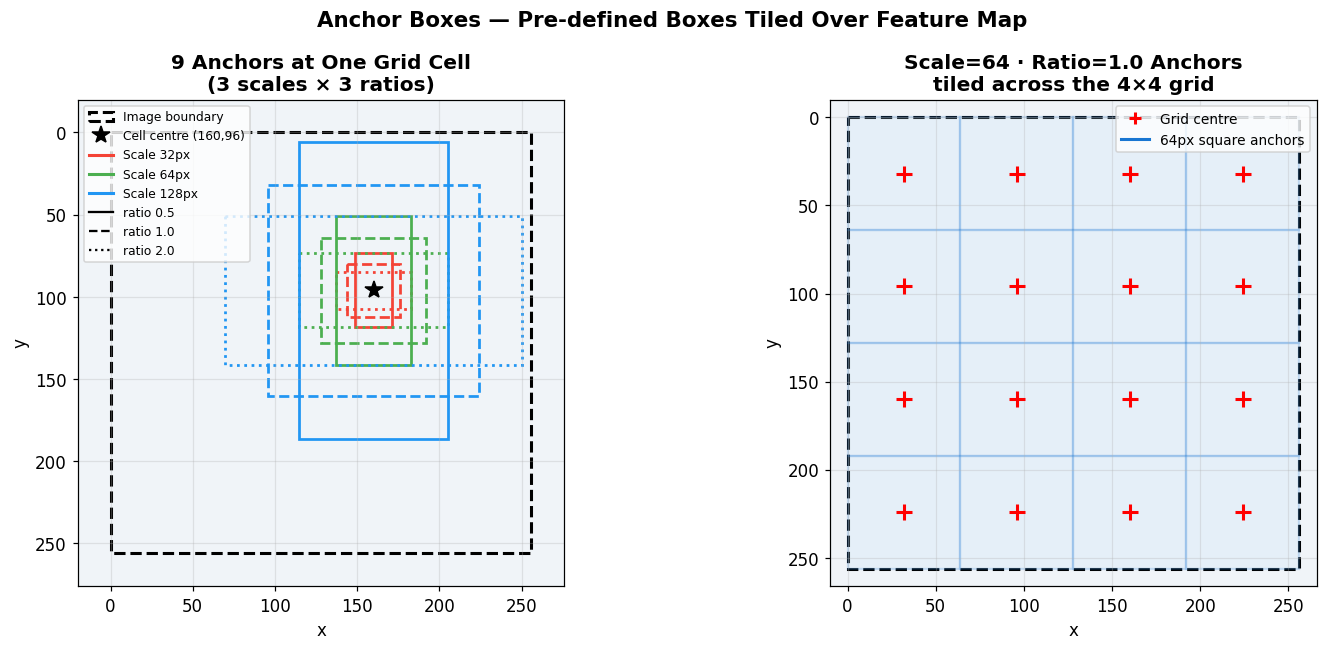

Saved: anchor_boxes.png


In [7]:
# ─── Anchor Visualisation ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: 9 anchors at a single grid cell ──
ax = axes[0]
ax.set_title('9 Anchors at One Grid Cell\n(3 scales × 3 ratios)', fontweight='bold')
ax.set_xlim(-20, 276); ax.set_ylim(276, -20)
ax.set_facecolor('#F0F4F8'); ax.grid(True, alpha=0.3)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')

img_rect = patches.Rectangle((0,0), 256, 256, linewidth=2,
                              edgecolor='black', facecolor='none',
                              linestyle='--', label='Image boundary')
ax.add_patch(img_rect)

scale_colors = ['#F44336', '#4CAF50', '#2196F3']
ratio_styles = ['-', '--', ':']

# Pick the cell at row=1, col=2  (roughly off-centre)
cell_row, cell_col = 1, 2
cx_cell = (cell_col + 0.5) * 64
cy_cell = (cell_row + 0.5) * 64

for si, scale in enumerate(SCALES):
    for ri, ratio in enumerate(RATIOS):
        w = scale * np.sqrt(ratio)
        h = scale / np.sqrt(ratio)
        rect = patches.Rectangle(
            (cx_cell-w/2, cy_cell-h/2), w, h,
            linewidth=1.8, edgecolor=scale_colors[si],
            facecolor='none', linestyle=ratio_styles[ri]
        )
        ax.add_patch(rect)

ax.plot(cx_cell, cy_cell, 'k*', ms=12, zorder=6, label=f'Cell centre ({cx_cell:.0f},{cy_cell:.0f})')
for si, s in enumerate(SCALES):
    ax.plot([], [], color=scale_colors[si], lw=2, label=f'Scale {s}px')
for ri, (st, lbl) in enumerate(zip(ratio_styles, ['ratio 0.5', 'ratio 1.0', 'ratio 2.0'])):
    ax.plot([], [], 'k', linestyle=st, lw=1.5, label=lbl)
ax.legend(fontsize=8, loc='upper left', ncol=1)

# ── Right: scale=64, ratio=1.0 across the full 4×4 grid ──
ax = axes[1]
ax.set_title('Scale=64 · Ratio=1.0 Anchors\ntiled across the 4×4 grid', fontweight='bold')
ax.set_xlim(-10, 266); ax.set_ylim(266, -10)
ax.set_facecolor('#F0F4F8'); ax.grid(True, alpha=0.3)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')

img_rect2 = patches.Rectangle((0,0), 256, 256, linewidth=2,
                               edgecolor='black', facecolor='none', linestyle='--')
ax.add_patch(img_rect2)

# Index 4 = scales[1]=64, ratios[1]=1.0 at each cell (step 9 anchors per cell)
sq_anchors = anchors[4::9]   # every 9th anchor starting from index 4
for anc in sq_anchors:
    r = patches.Rectangle((anc[0],anc[1]), anc[2]-anc[0], anc[3]-anc[1],
                           linewidth=1.5, edgecolor='#1976D2',
                           facecolor='#BBDEFB', alpha=0.2)
    ax.add_patch(r)

for row, col in product(range(4), range(4)):
    ax.plot((col+0.5)*64, (row+0.5)*64, 'r+', ms=10, mew=2)
ax.plot([], [], 'r+', ms=8, mew=2, label='Grid centre')
ax.plot([], [], color='#1976D2', lw=2, label='64px square anchors')
ax.legend(fontsize=9)

plt.suptitle('Anchor Boxes — Pre-defined Boxes Tiled Over Feature Map',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('anchor_boxes.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: anchor_boxes.png')

---
## 4. Non-Maximum Suppression (NMS)

After decoding predictions, the detector produces hundreds of overlapping boxes for each object (because many anchors near the object all fire). NMS collapses them to one.

### Greedy NMS Algorithm

```
Input:  boxes (N,4)  scores (N,)  iou_threshold θ
Output: indices of kept boxes

1. Sort all boxes by score (descending)
2. Take the highest-score box → mark it as KEPT
3. Compute IoU between this box and every remaining box
4. REMOVE all remaining boxes with IoU ≥ θ  (they are duplicates)
5. Repeat from step 2 on the surviving boxes
6. Stop when no boxes remain
```

**Typical thresholds:** `θ = 0.45` (strict) → `θ = 0.6` (lenient for dense scenes)

NMS runs **per class** — a car box should never suppress a person box even with high overlap.

In [8]:
# ─── Hard NMS from Scratch ──────────────────────────────────────────────────

def nms(boxes, scores, iou_threshold=0.5):
    """
    Greedy Non-Maximum Suppression.

    boxes  : np.ndarray (N, 4)  xyxy
    scores : np.ndarray (N,)
    Returns: list of indices of kept boxes (highest-score survivors)
    """
    order = np.argsort(scores)[::-1]   # sort descending by score
    keep  = []

    while len(order) > 0:
        i = order[0]          # highest remaining score
        keep.append(i)

        if len(order) == 1:
            break

        # IoU of kept box against all remaining boxes
        ious = np.array([compute_iou(boxes[i], boxes[j]) for j in order[1:]])
        order = order[1:][ious < iou_threshold]   # keep only low-overlap boxes

    return keep


# ─── Synthetic detection scenario ───────────────────────────────────────────
# Two objects: a car (top-left region) and a person (bottom-right region)
# Multiple noisy detections surround each object

boxes = np.array([
    [ 40,  40, 190, 200],   # 0 — car   (best)
    [ 45,  35, 195, 205],   # 1 — car   (duplicate)
    [ 38,  45, 185, 195],   # 2 — car   (duplicate)
    [ 50,  55, 180, 185],   # 3 — car   (duplicate)
    [210, 210, 380, 370],   # 4 — person (best)
    [215, 205, 385, 368],   # 5 — person (duplicate)
    [205, 215, 375, 375],   # 6 — person (duplicate)
    [130,  90, 280, 280],   # 7 — false positive
], dtype=float)

scores = np.array([0.95, 0.82, 0.76, 0.61, 0.93, 0.87, 0.69, 0.38])

kept       = nms(boxes, scores, iou_threshold=0.5)
suppressed = [i for i in range(len(boxes)) if i not in kept]

print(f'Input          : {len(boxes)} raw detections')
print(f'After NMS      : {len(kept)} kept  → indices {kept}')
print(f'Suppressed     : {len(suppressed)} removed → indices {suppressed}')
print()
for i in range(len(boxes)):
    status = 'KEPT      ←' if i in kept else 'suppressed'
    print(f'  box {i}  score={scores[i]:.2f}  {status}')

Input          : 8 raw detections
After NMS      : 3 kept  → indices [np.int64(0), np.int64(4), np.int64(7)]
Suppressed     : 5 removed → indices [1, 2, 3, 5, 6]

  box 0  score=0.95  KEPT      ←
  box 1  score=0.82  suppressed
  box 2  score=0.76  suppressed
  box 3  score=0.61  suppressed
  box 4  score=0.93  KEPT      ←
  box 5  score=0.87  suppressed
  box 6  score=0.69  suppressed
  box 7  score=0.38  KEPT      ←


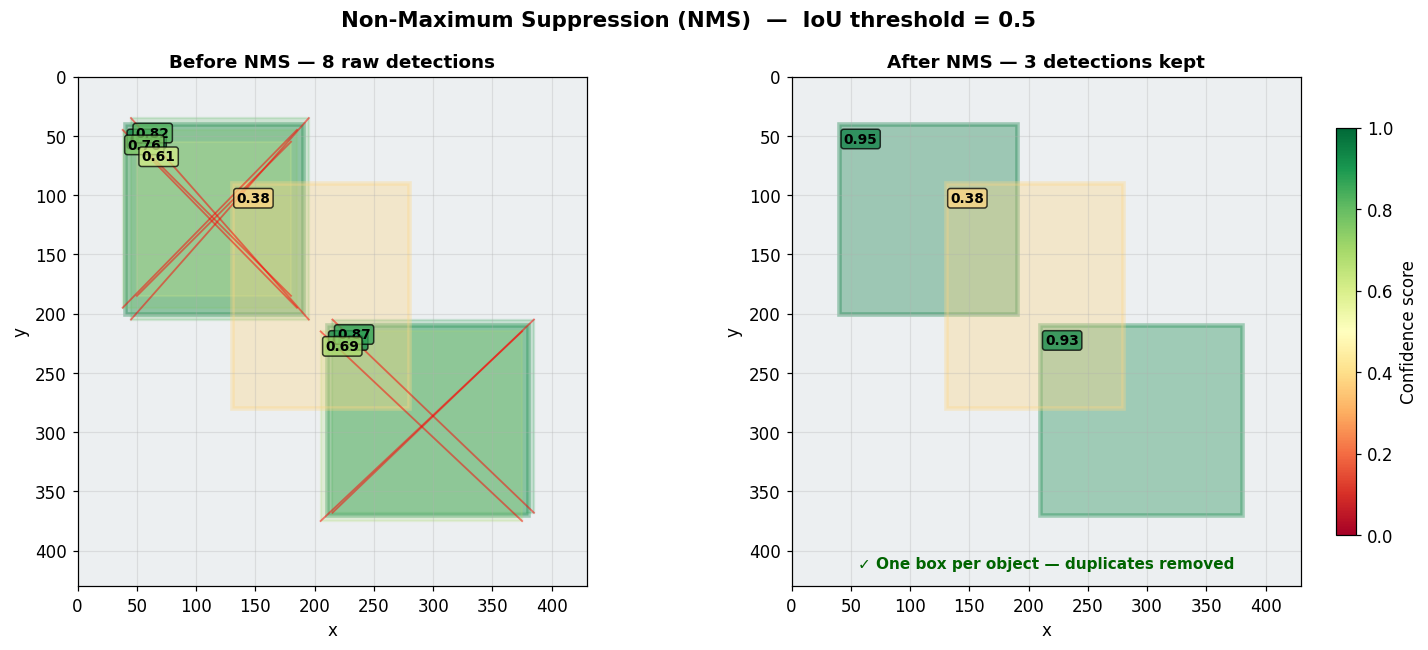

Saved: nms_visualization.png


In [9]:
# ─── NMS Visualisation ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap = plt.cm.RdYlGn

for ax_idx, (ax, title) in enumerate(zip(axes, ['Before NMS — 8 raw detections',
                                                  f'After NMS — {len(kept)} detections kept'])):
    ax.set_xlim(0, 430); ax.set_ylim(430, 0)
    ax.set_facecolor('#ECEFF1'); ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('x'); ax.set_ylabel('y')

    for i in range(len(boxes)):
        is_kept = i in kept

        # On the 'after' panel, skip suppressed boxes
        if ax_idx == 1 and not is_kept:
            continue

        color = cmap(scores[i])
        x1, y1, x2, y2 = boxes[i]
        lw    = 3.0 if is_kept else 1.5
        alpha = 0.35 if is_kept else 0.2

        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                  linewidth=lw, edgecolor=color,
                                  facecolor=color, alpha=alpha)
        ax.add_patch(rect)
        ax.text(x1+4, y1+16, f'{scores[i]:.2f}', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.75))

        # Mark suppressed boxes with an X on the 'before' panel
        if ax_idx == 0 and not is_kept:
            ax.plot([x1,x2],[y1,y2], 'r-', alpha=0.5, lw=1.2)
            ax.plot([x1,x2],[y2,y1], 'r-', alpha=0.5, lw=1.2)

    if ax_idx == 1:
        ax.text(215, 415, '✓ One box per object — duplicates removed',
               ha='center', color='darkgreen', fontsize=10, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
plt.colorbar(sm, ax=axes[1], label='Confidence score', shrink=0.8)
plt.suptitle('Non-Maximum Suppression (NMS)  —  IoU threshold = 0.5',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nms_visualization.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: nms_visualization.png')

---
## 5. Soft-NMS

**Problem with hard NMS:** In dense scenes (pedestrian crowds, fish schools), objects genuinely overlap with high IoU. Hard NMS deletes real detections because their IoU with a neighbour exceeds the threshold.

**Soft-NMS (Bodla et al., 2017):** Instead of removing overlapping boxes, *decay their scores* proportional to their IoU with the kept box:

$$s_j \leftarrow s_j \cdot \underbrace{e^{-\text{IoU}(\mathcal{M}, b_j)^2 / \sigma}}_{\text{Gaussian decay}}$$

- Boxes with IoU → 0 are unaffected  
- Boxes with IoU → 1 are strongly penalised  
- After decaying, only boxes with score < threshold are finally removed  
- `σ` controls how aggressively to penalise: smaller σ = more aggressive

In [10]:
# ─── Soft-NMS (Gaussian decay) ──────────────────────────────────────────────

def soft_nms(boxes, scores, sigma=0.5, score_threshold=0.3):
    """
    Soft-NMS with Gaussian score decay.

    scores_j ← scores_j × exp(-IoU(best, j)² / sigma)

    boxes          : (N, 4)  xyxy
    scores         : (N,)    confidence (modified in-place copy)
    sigma          : decay bandwidth — smaller = more suppression
    score_threshold: boxes below this after decay are discarded

    Returns: (kept_indices, final_scores)
    """
    boxes  = boxes.copy()
    scores = scores.copy().astype(float)
    N      = len(scores)
    keep   = []
    processed = np.zeros(N, dtype=bool)

    for _ in range(N):
        # Mask out already-processed boxes
        remaining = np.where(~processed)[0]
        if len(remaining) == 0:
            break

        best_idx = remaining[np.argmax(scores[remaining])]

        if scores[best_idx] < score_threshold:
            break

        keep.append(best_idx)
        processed[best_idx] = True

        # Decay scores of all remaining boxes
        for j in remaining:
            if j == best_idx:
                continue
            iou = compute_iou(boxes[best_idx], boxes[j])
            scores[j] *= np.exp(-(iou ** 2) / sigma)   # Gaussian decay

    return keep, scores


soft_kept, decayed_scores = soft_nms(boxes, scores, sigma=0.5, score_threshold=0.3)

print(f'Hard NMS kept: {sorted(kept)}')
print(f'Soft-NMS kept: {sorted(soft_kept)}')
print()
print(f'{"Box":<6} {"Original Score":<18} {"Decayed Score":<18} {"Status"}')
print('-' * 60)
for i in range(len(boxes)):
    hard_s = 'KEPT' if i in kept else 'removed'
    soft_s = 'KEPT' if i in soft_kept else 'removed'
    diff   = '← same' if hard_s == soft_s else '← DIFFERENT'
    print(f'{i:<6} {scores[i]:<18.3f} {decayed_scores[i]:<18.4f} hard={hard_s}  soft={soft_s}  {diff}')

Hard NMS kept: [np.int64(0), np.int64(4), np.int64(7)]
Soft-NMS kept: [np.int64(0), np.int64(4), np.int64(7)]

Box    Original Score     Decayed Score      Status
------------------------------------------------------------
0      0.950              0.9500             hard=KEPT  soft=KEPT  ← same
1      0.820              0.1642             hard=removed  soft=removed  ← same
2      0.760              0.1481             hard=removed  soft=removed  ← same
3      0.610              0.2202             hard=removed  soft=removed  ← same
4      0.930              0.9300             hard=KEPT  soft=KEPT  ← same
5      0.870              0.1667             hard=removed  soft=removed  ← same
6      0.690              0.1403             hard=removed  soft=removed  ← same
7      0.380              0.3579             hard=KEPT  soft=KEPT  ← same


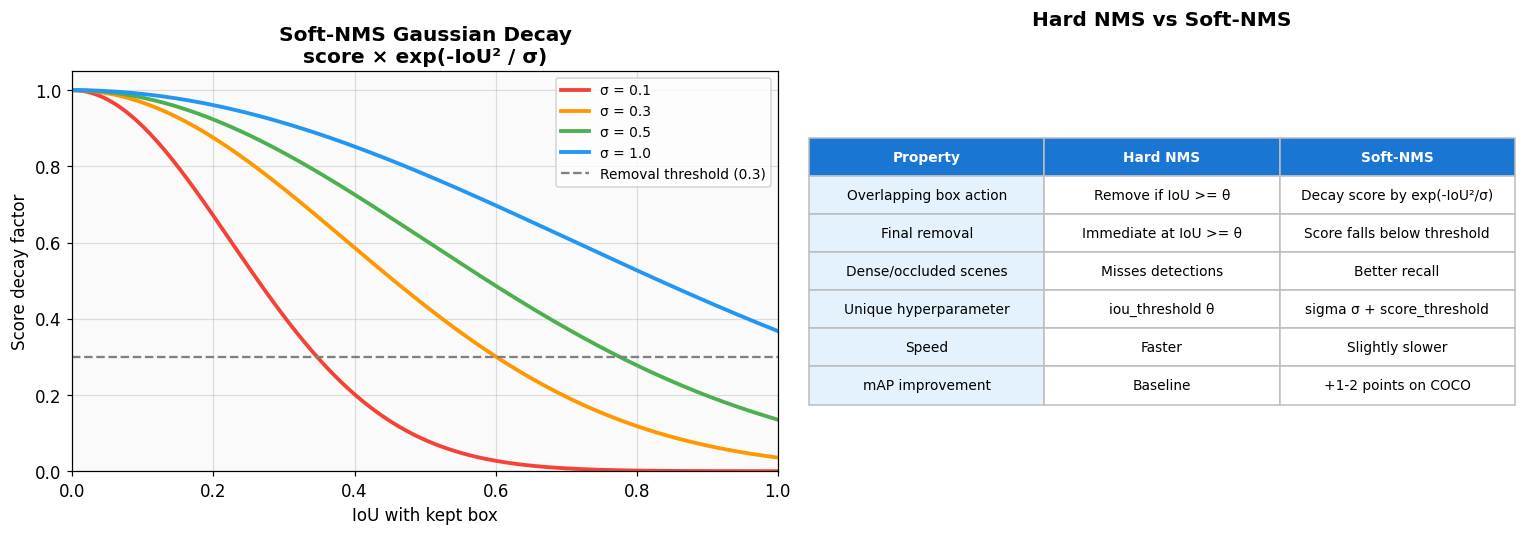

Saved: soft_nms_comparison.png


In [11]:
# ─── Score decay curve + algorithm comparison ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: score decay as a function of IoU for different sigma values
ax = axes[0]
iou_vals = np.linspace(0, 1, 200)
for sigma, color in [(0.1, '#F44336'), (0.3, '#FF9800'), (0.5, '#4CAF50'), (1.0, '#2196F3')]:
    decay = np.exp(-(iou_vals**2) / sigma)
    ax.plot(iou_vals, decay, color=color, lw=2.5, label=f'σ = {sigma}')

ax.axhline(0.3, color='gray', linestyle='--', lw=1.5, label='Removal threshold (0.3)')
ax.set_xlabel('IoU with kept box'); ax.set_ylabel('Score decay factor')
ax.set_title('Soft-NMS Gaussian Decay\nscore × exp(-IoU² / σ)', fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.4); ax.legend(fontsize=9)
ax.set_facecolor('#FAFAFA')

# Right: algorithm comparison table
ax = axes[1]
ax.axis('off')
table_data = [
    ['Property', 'Hard NMS', 'Soft-NMS'],
    ['Overlapping box action', 'Remove if IoU >= θ', 'Decay score by exp(-IoU²/σ)'],
    ['Final removal', 'Immediate at IoU >= θ', 'Score falls below threshold'],
    ['Dense/occluded scenes', 'Misses detections', 'Better recall'],
    ['Unique hyperparameter', 'iou_threshold θ', 'sigma σ + score_threshold'],
    ['Speed', 'Faster', 'Slightly slower'],
    ['mAP improvement', 'Baseline', '+1-2 points on COCO'],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.2)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1976D2')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 0:
        cell.set_facecolor('#E3F2FD')
    cell.set_edgecolor('#BDBDBD')
ax.set_title('Hard NMS vs Soft-NMS', fontweight='bold', pad=30)

plt.tight_layout()
plt.savefig('soft_nms_comparison.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: soft_nms_comparison.png')

---
## 6. Detection Head Design

The detection head sits on top of the backbone feature map and outputs predictions for every anchor. It is split into **two parallel branches**:

```
Feature Map (B, C, H, W)
        │
  Shared conv (optional)
        │
   ┌────┴────┐
   │         │
Cls Head   Reg Head
   │         │
(B, A×K,   (B, A×4,
  H, W)     H, W)
```

- **A** = anchors per cell, **K** = number of classes, **4** = (Δx, Δy, Δw, Δh)
- Classification loss: `FocalLoss` (RetinaNet) or `CrossEntropy`
- Regression loss: `SmoothL1` (Huber loss) — less sensitive to outlier boxes

### Weight initialisation trick (RetinaNet)
The classification head bias is initialised to `b = -log((1-π)/π)` where `π = 0.01`.  
This means the network outputs `P(object) ≈ 0.01` at the start — preventing the massive class-imbalance loss from dominating early training and causing instability.

In [12]:
# ─── Detection Head (Dual Branch) ───────────────────────────────────────────

class DetectionHead(nn.Module):
    """
    Parallel classification + regression head.
    Follows the RetinaNet design: 4 shared conv layers then task-specific heads.
    """
    def __init__(self, in_channels, num_anchors, num_classes, prior_prob=0.01):
        super().__init__()
        self.num_anchors = num_anchors
        self.num_classes = num_classes

        # Shared feature refinement — same weights used by both branches
        shared_layers = []
        for _ in range(4):
            shared_layers += [nn.Conv2d(in_channels, in_channels, 3, padding=1),
                              nn.ReLU(inplace=True)]
        self.shared = nn.Sequential(*shared_layers)

        # Task heads — final 1×1 conv
        self.cls_head = nn.Conv2d(in_channels, num_anchors * num_classes, kernel_size=1)
        self.reg_head = nn.Conv2d(in_channels, num_anchors * 4,           kernel_size=1)

        self._init_weights(prior_prob)

    def _init_weights(self, prior_prob):
        # Standard init for regression branch
        nn.init.normal_(self.reg_head.weight, std=0.01)
        nn.init.zeros_(self.reg_head.bias)

        # Classification bias trick: initialise so P(object) ≈ prior_prob
        # prevents foreground-background imbalance explosion at the start
        bias_value = -np.log((1 - prior_prob) / prior_prob)   # ≈ 4.6 for π=0.01
        nn.init.normal_(self.cls_head.weight, std=0.01)
        nn.init.constant_(self.cls_head.bias, bias_value)

    def forward(self, x):
        feat    = self.shared(x)
        cls_out = self.cls_head(feat)   # (B, A*K, H, W)
        reg_out = self.reg_head(feat)   # (B, A*4, H, W)
        return cls_out, reg_out


# ─── Forward pass demo ──────────────────────────────────────────────────────
B, C, H, W    = 2, 256, 8, 8
NUM_ANCHORS   = 9    # 3 scales × 3 ratios
NUM_CLASSES   = 4

head       = DetectionHead(C, NUM_ANCHORS, NUM_CLASSES)
feat_map   = torch.randn(B, C, H, W)
cls_out, reg_out = head(feat_map)

total_preds = H * W * NUM_ANCHORS
print(f'Input feature map      : {list(feat_map.shape)}')
print(f'Classification output  : {list(cls_out.shape)}  = (B, {NUM_ANCHORS}×{NUM_CLASSES}, H, W)')
print(f'Regression output      : {list(reg_out.shape)}  = (B, {NUM_ANCHORS}×4, H, W)')
print(f'Total anchor predictions: {H}×{W}×{NUM_ANCHORS} = {total_preds} per image')
print(f'  → Each predicts {NUM_CLASSES} class scores + 4 box offsets')

total_params = sum(p.numel() for p in head.parameters() if p.requires_grad)
print(f'\nDetection head params  : {total_params:,}')

# Confirm initial classification outputs near prior_prob via sigmoid
init_prob = torch.sigmoid(cls_out).mean().item()
print(f'Mean initial P(object) : {init_prob:.4f}  (target ≈ 0.01)')

Input feature map      : [2, 256, 8, 8]
Classification output  : [2, 36, 8, 8]  = (B, 9×4, H, W)
Regression output      : [2, 36, 8, 8]  = (B, 9×4, H, W)
Total anchor predictions: 8×8×9 = 576 per image
  → Each predicts 4 class scores + 4 box offsets

Detection head params  : 2,378,824
Mean initial P(object) : 0.0100  (target ≈ 0.01)


---
## 7. mAP — Mean Average Precision

mAP is the standard evaluation metric for object detection (used on COCO, VOC, Open Images).

### Computing mAP step by step

**Step 1:** For each class independently:
1. Collect all predictions across all images, sorted by score (descending)
2. For each prediction, check if it matches a GT box: IoU ≥ threshold (typically 0.5) → TP, else → FP
3. Each GT box can only be matched once (one-to-one matching)
4. Compute cumulative precision and recall over the sorted list

**Step 2:** Compute **AP** (Average Precision) = area under the Precision-Recall curve

$$AP = \sum_{k=1}^{N} (R_k - R_{k-1}) \cdot P_k$$

**Step 3:** $\text{mAP} = \frac{1}{C} \sum_{c=1}^{C} AP_c$ averaged over all classes

### COCO mAP variants
| Metric | IoU threshold(s) |
|--------|------------------|
| mAP@0.5 (VOC-style) | 0.5 only |
| mAP@0.75 (strict) | 0.75 only |
| mAP@[0.5:0.95] (COCO primary) | average over 0.5, 0.55, 0.60, ..., 0.95 |

In [13]:
# ─── mAP Implementation from Scratch ────────────────────────────────────────

def compute_ap(recalls, precisions):
    """
    Area under the Precision-Recall curve using all-point interpolation.
    Prepend (R=0, P=1) and append (R=1, P=0) to bound the curve.
    """
    recs  = np.concatenate([[0.0], recalls,    [1.0]])
    precs = np.concatenate([[1.0], precisions, [0.0]])

    # Monotonically decreasing precision envelope
    for i in range(len(precs)-2, -1, -1):
        precs[i] = max(precs[i], precs[i+1])

    # Area = sum of rectangular slabs (step function)
    idx = np.where(recs[1:] != recs[:-1])[0]
    ap  = np.sum((recs[idx+1] - recs[idx]) * precs[idx+1])
    return float(ap)


def match_preds_to_gt(pred_boxes, pred_scores, gt_boxes, iou_thr):
    """One-to-one greedy matching of predictions to GT boxes by descending score."""
    if len(pred_boxes) == 0:
        return [], []
    if len(gt_boxes) == 0:
        return [0]*len(pred_boxes), [1]*len(pred_boxes)

    order      = np.argsort(pred_scores)[::-1]
    gt_matched = [False] * len(gt_boxes)
    tps, fps   = [], []

    for idx in order:
        ious    = np.array([compute_iou(pred_boxes[idx], g) for g in gt_boxes])
        best_gt = int(np.argmax(ious))
        if ious[best_gt] >= iou_thr and not gt_matched[best_gt]:
            tps.append(1); fps.append(0)
            gt_matched[best_gt] = True
        else:
            tps.append(0); fps.append(1)

    return tps, fps


def compute_map(predictions, ground_truths, num_classes, iou_threshold=0.5):
    """
    predictions  : list of dicts — {'boxes': (N,4), 'scores': (N,), 'labels': (N,)}
    ground_truths: list of dicts — {'boxes': (M,4), 'labels': (M,)}
    Returns: mAP scalar, dict of per-class APs
    """
    aps = {}
    for cls in range(num_classes):
        all_tp, all_fp, all_sc = [], [], []
        n_gt_total = 0

        for pred, gt in zip(predictions, ground_truths):
            pm = pred['labels'] == cls
            gm = gt['labels']  == cls
            pb = pred['boxes'][pm];  ps = pred['scores'][pm]
            gb = gt['boxes'][gm]
            n_gt_total += len(gb)

            if len(pb) == 0:
                continue

            tps, fps = match_preds_to_gt(pb.tolist(), ps, gb.tolist(), iou_threshold)
            all_tp.extend(tps);  all_fp.extend(fps)
            all_sc.extend(ps.tolist())

        if n_gt_total == 0:
            aps[cls] = 0.0
            continue

        sort_idx = np.argsort(all_sc)[::-1]
        tp_cum   = np.cumsum(np.array(all_tp)[sort_idx])
        fp_cum   = np.cumsum(np.array(all_fp)[sort_idx])

        recalls    = tp_cum / (n_gt_total + 1e-6)
        precisions = tp_cum / (tp_cum + fp_cum + 1e-6)

        aps[cls] = compute_ap(recalls, precisions)

    mAP = float(np.mean(list(aps.values())))
    return mAP, aps


# ─── Synthetic 3-class detection scenario ───────────────────────────────────
np.random.seed(7)

def rand_boxes(n, img=400, min_sz=40, max_sz=140):
    out = []
    for _ in range(n):
        x1 = np.random.randint(0, img-max_sz)
        y1 = np.random.randint(0, img-max_sz)
        w  = np.random.randint(min_sz, max_sz)
        h  = np.random.randint(min_sz, max_sz)
        out.append([x1, y1, x1+w, y1+h])
    return np.array(out, dtype=float)

def jitter(box, noise=12):
    return np.clip(np.array(box, dtype=float) + np.random.randint(-noise, noise, 4), 0, 400).tolist()

CLASS_NAMES = ['car', 'person', 'bicycle']

ground_truths = [
    {'boxes': rand_boxes(4), 'labels': np.array([0,0,1,2])},
    {'boxes': rand_boxes(3), 'labels': np.array([0,1,1])},
    {'boxes': rand_boxes(5), 'labels': np.array([0,1,1,2,2])},
]
predictions = []
for gt in ground_truths:
    pb, ps, pl = [], [], []
    for b, l in zip(gt['boxes'].tolist(), gt['labels'].tolist()):
        pb.append(jitter(b, 12));  ps.append(np.random.uniform(0.70, 0.97));  pl.append(l)
    for b in rand_boxes(2).tolist():   # false positives
        pb.append(b);  ps.append(np.random.uniform(0.20, 0.55));  pl.append(np.random.randint(0,3))
    predictions.append({'boxes': np.array(pb), 'scores': np.array(ps), 'labels': np.array(pl)})

mAP_val, per_cls_ap = compute_map(predictions, ground_truths, num_classes=3, iou_threshold=0.5)

print('=' * 42)
print(f'  {"Class":<12}  AP@0.5')
print('-' * 42)
for c, name in enumerate(CLASS_NAMES):
    print(f'  {name:<12}  {per_cls_ap[c]:.4f}')
print('-' * 42)
print(f'  {"mAP@0.5":<12}  {mAP_val:.4f}')
print('=' * 42)

  Class         AP@0.5
------------------------------------------
  car           1.0000
  person        1.0000
  bicycle       1.0000
------------------------------------------
  mAP@0.5       1.0000


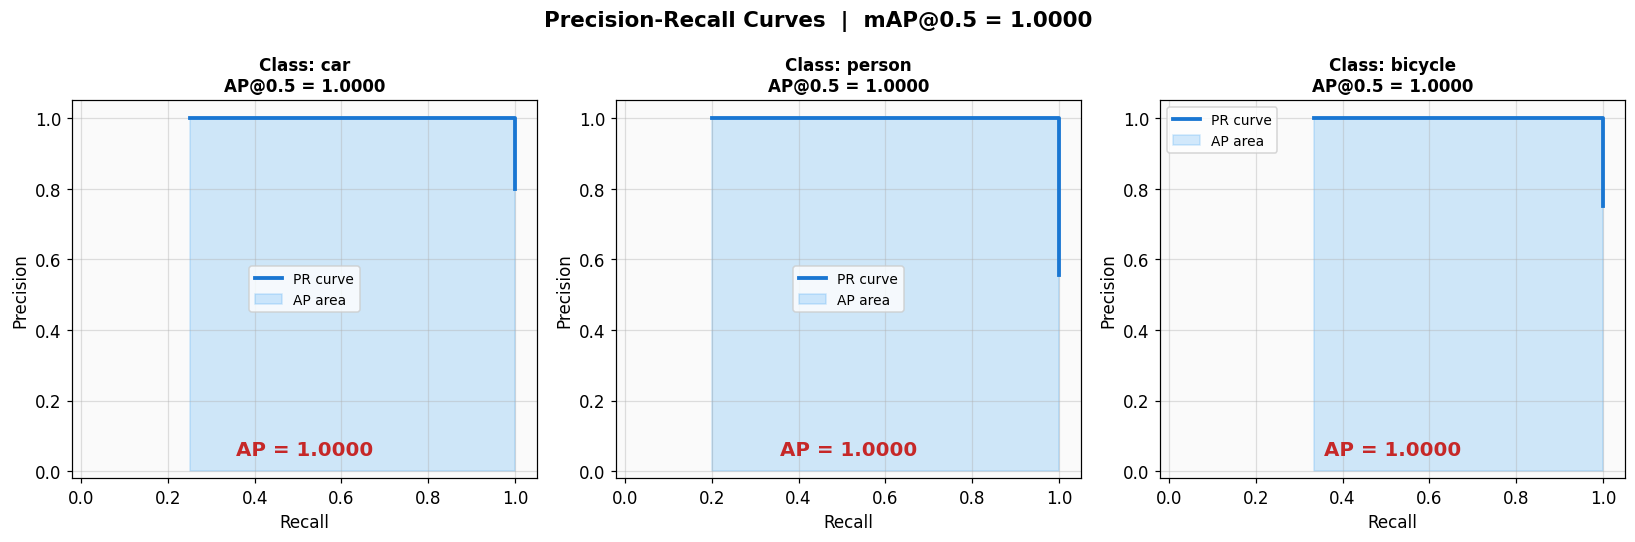

Saved: map_pr_curves.png


In [14]:
# ─── Precision-Recall Curves + mAP Visualisation ────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cls_id in zip(axes, range(3)):
    all_tp, all_fp, all_sc = [], [], []
    n_gt = sum(np.sum(gt['labels'] == cls_id) for gt in ground_truths)

    for pred, gt in zip(predictions, ground_truths):
        pm = pred['labels'] == cls_id
        gm = gt['labels']  == cls_id
        pb = pred['boxes'][pm]; ps = pred['scores'][pm]
        gb = gt['boxes'][gm]
        if len(pb) == 0:
            continue
        tps, fps = match_preds_to_gt(pb.tolist(), ps, gb.tolist(), 0.5)
        all_tp.extend(tps); all_fp.extend(fps); all_sc.extend(ps.tolist())

    if all_tp:
        sort_idx = np.argsort(all_sc)[::-1]
        tp_cum   = np.cumsum(np.array(all_tp)[sort_idx])
        fp_cum   = np.cumsum(np.array(all_fp)[sort_idx])
        rec  = tp_cum / (n_gt + 1e-6)
        prec = tp_cum / (tp_cum + fp_cum + 1e-6)

        # Plot raw and interpolated curve
        ax.step(rec, prec, where='post', color='#1976D2', lw=2.5, label='PR curve')
        ax.fill_between(rec, prec, step='post', alpha=0.2, color='#2196F3', label='AP area')

    ap = per_cls_ap[cls_id]
    ax.set_title(f'Class: {CLASS_NAMES[cls_id]}\nAP@0.5 = {ap:.4f}',
                fontweight='bold', fontsize=11)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_xlim(-0.02, 1.05); ax.set_ylim(-0.02, 1.05)
    ax.grid(True, alpha=0.4); ax.set_facecolor('#FAFAFA')
    ax.legend(fontsize=9)
    ax.text(0.5, 0.06, f'AP = {ap:.4f}', transform=ax.transAxes,
           ha='center', fontsize=13, color='#C62828', fontweight='bold')

plt.suptitle(f'Precision-Recall Curves  |  mAP@0.5 = {mAP_val:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('map_pr_curves.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: map_pr_curves.png')

---
## Summary

### What we built today (all from scratch)

| Component | Key Formula / Insight |
|-----------|----------------------|
| **BBox formats** | `xyxy` for intersection math; `cxcywh` for offset regression |
| **IoU** | `intersection / (area1 + area2 − intersection)` — clamp to 0 when no overlap |
| **Batched IoU** | (N,1,4) broadcast with (1,M,4) → (N,M) matrix in one pass |
| **Anchor boxes** | `w = scale × √ratio`, `h = scale / √ratio` at every grid centre |
| **Hard NMS** | Sort by score → keep top → remove IoU ≥ θ → repeat |
| **Soft-NMS** | `score_j ← score_j × exp(−IoU²/σ)` — better recall in dense scenes |
| **Detection Head** | Dual branch: cls (A×K) + reg (A×4), bias init for class imbalance |
| **mAP** | Per-class AP = area under PR curve → average across classes |

### Output files
- `bbox_formats.png` — xyxy vs cxcywh side-by-side
- `iou_visualization.png` — 3 IoU cases with intersection highlighted
- `anchor_boxes.png` — multi-scale anchor grid visualisation
- `nms_visualization.png` — before/after NMS detection suppression
- `soft_nms_comparison.png` — Gaussian decay curve + Hard vs Soft comparison
- `map_pr_curves.png` — per-class PR curves with AP scores

### Next — Tuesday (Jun 16): R-CNN Family
R-CNN → Fast R-CNN → Faster R-CNN — Region Proposal Networks (RPN), ROI Pooling vs ROI Align, and running Faster R-CNN inference on COCO.